# Plot Bethe Roots

Set `csv_path` to a `Result_SYT/*.csv` file, run the cells, and the notebook will parse the `BetheRoots` field and plot the roots in the complex plane.

In [1]:
from pathlib import Path
import ast
import csv
import os
import re

Path('.matplotlib').mkdir(exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(Path('.matplotlib').resolve()))

import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print


In [2]:
# Change this path to plot a different SYT result CSV.
csv_path = Path('/home/zuxian/Documents/Bertini/Result_SYT/{{1, 2, 3, 5, 8, 9, 11, 15}, {4, 6, 7, 10, 12, 13, 14, 16}}.csv')
csv_path


PosixPath('/home/zuxian/Documents/Bertini/Result_SYT/{{1, 2, 3, 5, 8, 9, 11, 15}, {4, 6, 7, 10, 12, 13, 14, 16}}.csv')

In [3]:
PRECISION_RE = re.compile(r'`(?:\d+(?:\.\d*)?|\.\d+)?')
SCIENTIFIC_RE = re.compile(
    r'(?<![A-Za-z0-9_.])([+-]?(?:\d+(?:\.\d*)?|\.\d+))(?:`\d+(?:\.\d*)?)?\*(?:10)?\^([+-]?\d+)'
)


def mathematica_to_python_expression(text):
    text = str(text).strip()
    text = SCIENTIFIC_RE.sub(r'\\1e\\2', text)
    text = PRECISION_RE.sub('', text)
    text = text.replace('{', '[').replace('}', ']')
    text = text.replace('*I', 'j')
    text = re.sub(r'(?<![A-Za-z0-9_])I(?![A-Za-z0-9_])', '1j', text)
    return text


def flatten(items):
    if isinstance(items, (list, tuple)):
        for item in items:
            yield from flatten(item)
    else:
        yield items


def parse_bethe_roots(raw):
    raw = str(raw).strip()
    if raw == '' or raw.startswith('Missing'):
        return []
    expression = mathematica_to_python_expression(raw)
    parsed = ast.literal_eval(expression)
    return [complex(value) for value in flatten(parsed)]


def load_bethe_roots(path):
    path = Path(path)
    with path.open(newline='') as handle:
        rows = list(csv.DictReader(handle))
    if not rows:
        raise ValueError(f'No rows found in {path}')
    row = rows[0]
    roots = parse_bethe_roots(row.get('BetheRoots', ''))
    return row, roots


## Compare Two SYT Files

This reproduces the Mathematica idea `ComplexListPlot[{-r1, r2}]`: roots from the first file are sign-flipped and plotted together with roots from the second file.

In [4]:
def complex_list_plot(root_sets, labels=None, colors=None, markers=None, title=None, output_png=None, annotate=True):
    labels = labels or [f'set {index}' for index in range(1, len(root_sets) + 1)]
    colors = colors or ['#d62728', '#1f77b4', '#2ca02c', '#9467bd']
    markers = markers or ['o', 'x', '^', 's']

    all_roots = [root for roots in root_sets for root in roots]
    if not all_roots:
        raise ValueError('No roots to plot.')

    fig, ax = plt.subplots(figsize=(7, 6))
    for set_index, roots_for_set in enumerate(root_sets):
        label = labels[set_index]
        color = colors[set_index % len(colors)]
        marker = markers[set_index % len(markers)]
        xs = [root.real for root in roots_for_set]
        ys = [root.imag for root in roots_for_set]
        scatter_kwargs = dict(s=80, color=color, marker=marker, linewidth=1.5, zorder=3, label=label)
        if marker not in {'x', '+', '1', '2', '3', '4'}:
            scatter_kwargs.update(edgecolor='white', linewidth=0.8)
        ax.scatter(xs, ys, **scatter_kwargs)

        if annotate:
            for root_index, root in enumerate(roots_for_set, start=1):
                ax.annotate(
                    f'{label}:{root_index}',
                    (root.real, root.imag),
                    xytext=(6, 6),
                    textcoords='offset points',
                    fontsize=8,
                    color=color,
                )

    xs = [root.real for root in all_roots]
    ys = [root.imag for root in all_roots]
    x_span = max(xs) - min(xs)
    y_span = max(ys) - min(ys)
    x_pad = max(0.05, 0.12 * (x_span if x_span else 1.0))
    y_pad = max(0.05, 0.12 * (y_span if y_span else 1.0))

    ax.axhline(0, color='0.55', linewidth=0.9, zorder=1)
    ax.axvline(0, color='0.55', linewidth=0.9, zorder=1)
    ax.grid(True, color='0.88', linewidth=0.8)
    ax.set_xlabel('Re(root)')
    ax.set_ylabel('Im(root)')
    ax.set_title(title or 'Complex roots')
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(min(xs) - x_pad, max(xs) + x_pad)
    ax.set_ylim(min(ys) - y_pad, max(ys) + y_pad)
    ax.legend(loc='best')

    if output_png is not None:
        fig.savefig(output_png, dpi=200, bbox_inches='tight')
        print('Saved plot:', output_png)

    return fig, ax


def greedy_root_match(left_roots, right_roots):
    if len(left_roots) != len(right_roots):
        raise ValueError(f'Root counts differ: {len(left_roots)} vs {len(right_roots)}')

    remaining = set(range(len(right_roots)))
    pairs = []
    for left_index, left_root in enumerate(left_roots):
        right_index = min(remaining, key=lambda index: abs(left_root - right_roots[index]))
        remaining.remove(right_index)
        distance = abs(left_root - right_roots[right_index])
        pairs.append((left_index, right_index, distance))
    return pairs


def plot_flipped_bethe_roots(path_r1, path_r2, output_png=None, annotate=True):
    path_r1 = Path(path_r1)
    path_r2 = Path(path_r2)
    row1, r1 = load_bethe_roots(path_r1)
    row2, r2 = load_bethe_roots(path_r2)
    minus_r1 = [-root for root in r1]

    pairs = greedy_root_match(minus_r1, r2)
    distances = [distance for _, _, distance in pairs]
    max_distance = max(distances) if distances else 0.0
    rms_distance = (sum(distance * distance for distance in distances) / len(distances)) ** 0.5 if distances else 0.0

    if output_png is None:
        output_png = path_r2.with_suffix('.minus_r1_vs_r2.png')

    title = f'ComplexListPlot[{{-r1, r2}}]  max={max_distance:.3g}, rms={rms_distance:.3g}'
    fig, ax = complex_list_plot(
        [minus_r1, r2],
        labels=['-r1', 'r2'],
        title=title,
        output_png=output_png,
        annotate=annotate,
    )

    print('r1:', path_r1)
    print('r2:', path_r2)
    print('SucceededQ:', row1.get('SucceededQ'), row2.get('SucceededQ'))
    print('Number of roots:', len(r1), len(r2))
    print(f'max |(-r1)-r2|: {max_distance:.16g}')
    print(f'rms |(-r1)-r2|: {rms_distance:.16g}')
    return fig, ax, {'row1': row1, 'row2': row2, 'r1': r1, 'r2': r2, 'minus_r1': minus_r1, 'pairs': pairs}


Saved plot: Result_SYT/{{1, 2, 5, 6, 7, 8, 9, 10, 16}, {3, 4, 11, 12, 13, 14, 15}}.minus_r1_vs_r2.png
r1: Result_SYT/{{1, 2, 3, 4, 5, 6, 12, 13, 14}, {7, 8, 9, 10, 11, 15, 16}}.csv
r2: Result_SYT/{{1, 2, 5, 6, 7, 8, 9, 10, 16}, {3, 4, 11, 12, 13, 14, 15}}.csv
SucceededQ: true true
Number of roots: 7 7
max |(-r1)-r2|: 0.7659999994199624
rms |(-r1)-r2|: 0.5775368085670769


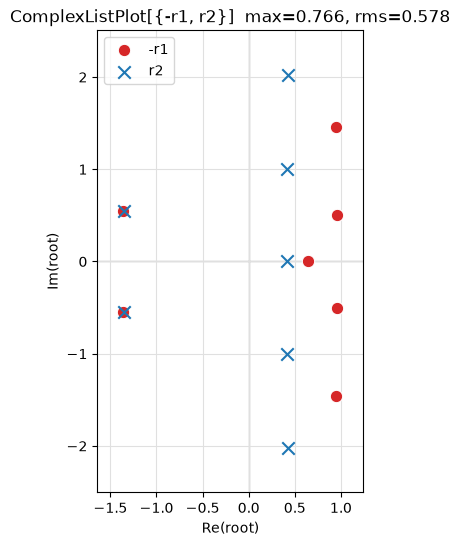

In [5]:
path_r1 = Path('Result_SYT/{{1, 2, 3, 4, 5, 6, 12, 13, 14}, {7, 8, 9, 10, 11, 15, 16}}.csv')
path_r2 = Path('Result_SYT/{{1, 2, 5, 6, 7, 8, 9, 10, 16}, {3, 4, 11, 12, 13, 14, 15}}.csv')

fig, ax, comparison = plot_flipped_bethe_roots(path_r1, path_r2, annotate=False)
plt.show()


Saved plot: Result_SYT/{{1, 3, 4, 5, 6, 7, 8, 9, 15}, {2, 10, 11, 12, 13, 14}}.minus_r1_vs_r2.png
r1: Result_SYT/{{1, 2, 3, 4, 5, 6, 12, 13, 14}, {7, 8, 9, 10, 11, 15}}.csv
r2: Result_SYT/{{1, 3, 4, 5, 6, 7, 8, 9, 15}, {2, 10, 11, 12, 13, 14}}.csv
SucceededQ: true true
Number of roots: 6 6
max |(-r1)-r2|: 0
rms |(-r1)-r2|: 0


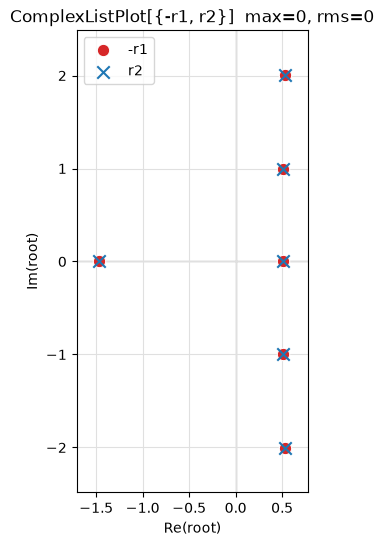

In [6]:
path_r1 = Path('Result_SYT/{{1, 2, 3, 4, 5, 6, 12, 13, 14}, {7, 8, 9, 10, 11, 15}}.csv')
path_r2 = Path('Result_SYT/{{1, 3, 4, 5, 6, 7, 8, 9, 15}, {2, 10, 11, 12, 13, 14}}.csv')

fig, ax, comparison = plot_flipped_bethe_roots(path_r1, path_r2, annotate=False)
plt.show()


Saved plot: Result_SYT/{{1, 2, 3, 4, 5, 6, 7, 8, 14}, {9, 10, 11, 12, 13}}.minus_r1_vs_r2.png
r1: Result_SYT/{{1, 2, 3, 4, 5, 6, 12, 13, 14}, {7, 8, 9, 10, 11}}.csv
r2: Result_SYT/{{1, 2, 3, 4, 5, 6, 7, 8, 14}, {9, 10, 11, 12, 13}}.csv
SucceededQ: true true
Number of roots: 5 5
max |(-r1)-r2|: 0
rms |(-r1)-r2|: 0


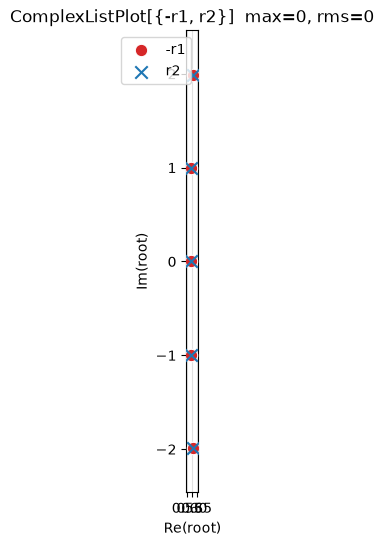

In [7]:
path_r1 = Path('Result_SYT/{{1, 2, 3, 4, 5, 6, 12, 13, 14}, {7, 8, 9, 10, 11}}.csv')
path_r2 = Path('Result_SYT/{{1, 2, 3, 4, 5, 6, 7, 8, 14}, {9, 10, 11, 12, 13}}.csv')

fig, ax, comparison = plot_flipped_bethe_roots(path_r1, path_r2, annotate=False)
plt.show()
